In [3]:
from IPython.display import display, HTML, Image
display(HTML("<style>.container { width:100% !important; }</style>"))

from hashlib import md5

import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib.colors import ListedColormap
from tqdm import tqdm

from scipy.stats import chi2_contingency, chi2, ttest_ind_from_stats, norm, binom, mannwhitneyu, t, chisquare
import statsmodels.formula.api as smf
from statsmodels.stats.proportion import proportion_confint 

from datetime import datetime
pd.set_option('display.max_colwidth', None)

from exp_tools.stat_tools import * 

import plotly.offline as pyo
import plotly.io as pio
pio.renderers.default = 'iframe'


In [4]:
def vertical_plot_lines(x, xal, yal, **kwargs):
    plt.axvline(x.mean(), linestyle = '--', color = kwargs.get("color", "g"), alpha = 0.5)
    tx_mean = "mean: {:.1%}".format(x.mean())
    txkw = dict(size=11, color = kwargs.get("color", "g"), rotation=90)
    plt.text(x.mean()+xal, yal, tx_mean, **txkw)


def plot_distribution(df, metric, **kwargs):
    g = sns.FacetGrid(
        data=df,
        aspect=3, height = 5,
        hue = 'variant', row = kwargs.get('row',None)
    ) 
    g.map(sns.distplot, metric, hist=kwargs.get('displot_hist',False), kde_kws={'bw': kwargs.get('kde_bandwidth','silverman')})
    g.map(vertical_plot_lines, metric, xal=  kwargs.get('xal',0.10), yal=kwargs.get('yal',0.5))
    g.fig.suptitle("Distribution between variants - {}".format(metric))
    g.set_xlabels("{}".format(metric))
    g.set_ylabels("density")
    g.set(xlim = kwargs.get('xlim', (-10,10)))
    g.add_legend()
    plt.subplots_adjust(top=0.9)
    for ax in g.axes:
        ax[0].axvline(x=0, color="black", ls=':')

In [5]:
from scipy.stats import chi2_contingency, chi2, ttest_ind_from_stats, norm, binom, mannwhitneyu, t, chisquare
from statsmodels.stats.proportion import proportion_confint 

def calculate_req_traffic_for_power(alpha, beta, base_rate, expected_effect):
    za = norm.ppf(1 - alpha/2)
    zb = norm.ppf(1 - beta)
    mde = (base_rate * expected_effect) 
    sigma = np.sqrt((base_rate) * (1-base_rate))
    sample_size_variant = 2 * (sigma**2) * (za + zb)**2 / (mde**2)
    return int(sample_size_variant)

def calculate_mde_from_traffic(alpha, beta, base_rate, n_variant):
    za = norm.ppf(1 - alpha/2)
    zb = norm.ppf(1 - beta)
    sigma = np.sqrt((base_rate) * (1-base_rate))
    
    mde = np.sqrt(2 * (sigma**2) * (za + zb)**2 / n_variant)
    
#     print(
#         f'MDE (percentage effect) = {mde/base_rate:.2%}',
#         f'\nMDE (absolute effect) = {base_rate:.2%} +- {mde:.2%}',
#         f'\nEffect identifiable outside the range [{base_rate - mde:.2%},{base_rate + mde:.2%}]\n------'
#     )
    
    return mde / BASE_RATE


ALPHA = 0.05
BETA = 0.2 # (1 - power)
BASE_RATE = 0.05
N_VARIANT = 20000

EXPECTED_UPLIFT_PERC = 0.05
N_VARIANTS = 2
N_DAYS = 14

print(
      f'MDE (absolute effect) = +- {BASE_RATE*(1+EXPECTED_UPLIFT_PERC) - BASE_RATE:.2%}',
      f'\nEffect identifiable outside the range [{BASE_RATE*(1-EXPECTED_UPLIFT_PERC):.2%},{BASE_RATE*(1+EXPECTED_UPLIFT_PERC):.2%}]\n------'
)

req_total_exp_traffic = calculate_req_traffic_for_power(
    alpha=ALPHA, 
    beta=BETA, 
    base_rate=BASE_RATE, 
    expected_effect=EXPECTED_UPLIFT_PERC)

req_daily_traffic = req_total_exp_traffic / (N_DAYS)
print(f'{req_total_exp_traffic:.0f} \t=== Total required unique visitors per variant')
print(f'{req_daily_traffic:.0f} \t=== Required daily unique visitors per variant, for experiment run of {N_DAYS} days')
print(f'\n{req_total_exp_traffic*N_VARIANTS:.0f} \t=== Total required visitors\n--------')

calculate_mde_from_traffic(
    alpha=ALPHA, 
    beta=BETA, 
    base_rate=BASE_RATE, 
    n_variant=req_total_exp_traffic
) 

MDE (absolute effect) = +- 0.25% 
Effect identifiable outside the range [4.75%,5.25%]
------
119302 	=== Total required unique visitors per variant
8522 	=== Required daily unique visitors per variant, for experiment run of 14 days

238604 	=== Total required visitors
--------


np.float64(0.0500002036764108)

# Simulating non-inferiority

In [6]:
ALPHA = 0.05 # two sided
BETA = 0.2 # (1 - power)
BASE_RATE = 0.05
TRUE_EFFECT = 0.07
SAMPLE_SIZE = int(250000) # 238604



responses = {}
for i in tqdm(range(100)):
    df_exp = pd.DataFrame({'variant': np.round(np.random.uniform(0,1,SAMPLE_SIZE))})

    df_exp['metric'] = np.random.binomial(
        n=1, 
        p=BASE_RATE, 
        size=SAMPLE_SIZE
    )

    df_exp.loc[df_exp.variant == 1, 'metric'] = np.random.binomial(
        n=1, 
        p=BASE_RATE * (1 + TRUE_EFFECT), 
        size=df_exp.loc[df_exp.variant == 1, 'metric'].shape[0]
    )


    # Test statistical power
    req_traffic = calculate_req_traffic_for_power(
        alpha=ALPHA, 
        beta=BETA, 
        base_rate=BASE_RATE, 
        expected_effect=TRUE_EFFECT)

#     print(f'\nRequired unique visitors per variant for experiment with {1-BETA:.0%} power and {ALPHA:.0%} false positive rate ===> {req_traffic:.0f}')
#     print(f'Actual traffic per variant ===> {SAMPLE_SIZE/2:.0f}')
#     print(f'Experiment is Powered: *** {SAMPLE_SIZE/2 >= req_traffic} ***\n===')

    actual_mde = calculate_mde_from_traffic(
        alpha=ALPHA, 
        beta=BETA, 
        base_rate=BASE_RATE, 
        n_variant=SAMPLE_SIZE/2
    )
#     print(f'True effect: {TRUE_EFFECT:.2%}, MDE: {actual_mde:.2%}\n======\n')

    # Get experiment results per metric (Elaborate)

    response = get_results(
        df_exp, 
        metric_field='metric', 
        confidence=0.9, 
        threshold=None, 
        calculate_ratio=True,
        plot=False
        
    )
    
    responses[i] = response

  0%|                                                                                                                                                                                                                                                   | 0/100 [00:00<?, ?it/s]

metric


pval = 0.00009, significant at 10%: True


    variant  visitors  reached_goal  average_value      stdv  binary
0      0.0    124714          6267       0.050251  0.218463    True
1      1.0    125286          6731       0.053725  0.225475    True 

Estimate: 6.914%,     CI = [0.03951, 0.09964]


  1%|██▎                                                                                                                                                                                                                                        | 1/100 [00:00<00:19,  4.96it/s]

metric


pval = 0.00029, significant at 10%: True


    variant  visitors  reached_goal  average_value      stdv  binary
0      0.0    125500          6298       0.050183  0.218324    True
1      1.0    124500          6648       0.053398  0.224826    True 

Estimate: 6.405%,     CI = [0.03451, 0.09446]


metric


pval = 0.00003, significant at 10%: True


    variant  visitors  reached_goal  average_value      stdv  binary
0      0.0    125201          6262       0.050016  0.217978    True
1      1.0    124799          6701       0.053694  0.225414    True 

Estimate: 7.355%,     CI = [0.04376, 0.10423]


...

 97%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉       | 97/100 [00:03<00:00, 27.83it/s]

metric


pval = 0.00210, significant at 10%: True


    variant  visitors  reached_goal  average_value      stdv  binary
0      0.0    125293          6344       0.050633  0.219249    True
1      1.0    124707          6655       0.053365  0.224761    True 

Estimate: 5.395%,     CI = [0.02475, 0.08401]


metric


pval = 0.00322, significant at 10%: True


    variant  visitors  reached_goal  average_value      stdv  binary
0      0.0    125063          6363       0.050878  0.219750    True
1      1.0    124937          6684       0.053499  0.225027    True 

Estimate: 5.151%,     CI = [0.02243, 0.08143]


metric


pval = 0.00000, significant at 10%: True


    variant  visitors  reached_goal  average_value      stdv  binary
0      0.0    125089          6147       0.049141  0.216163    True
1      1.0    124911          6684       0.053510  0.225049    True 

Estimate: 8.891%,     CI = [0.05852, 0.12021]


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:03<00:00, 25.36it/s]


In [7]:
def get_results(data, metric_field, confidence=0.9, threshold=None, calculate_ratio=True, **kwargs):
    df_stats = get_df_stats(data, metric_field)
    stats = get_stats(df_stats, non_inferioirity_threshold=threshold)
    
    if (threshold is not None):
        confidence = 1 - (1 - confidence)*2
        
    if kwargs.get('mannwhitney'):
        get_mann_whitney_test(data, metric_field, confidence)
    
    if kwargs.get('plot') is not None:
        plot_arg = kwargs.get('plot')
    else:
        plot_arg = False
        

    estimate, ci_l, ci_h = get_ci(
        df_stats,
        metric_field,
        confidence=confidence, 
        plot = plot_arg, 
        non_inferioirty_threshold=threshold,
        ratio = calculate_ratio
    )
    
    response = {'estimate':estimate,
                'ci_l':ci_l, 
                'ci_h':ci_h,
                'p-value': stats['p-value']
               }
    
    return response


def get_ci(df_stats, metric_field, confidence=0.9, plot = True, non_inferioirty_threshold=None, ratio=True):
    
    if df_stats['binary'].all() == True:
        estimate, ci_l, ci_h = improv_interval_binomial(
            confidence = confidence, 
            successes_base=df_stats.at[0, 'reached_goal'], 
            successes_var=df_stats.at[1, 'reached_goal'], 
            obs_base=df_stats.at[0, 'visitors'], 
            obs_var=df_stats.at[1, 'visitors'])
        # print("Estimate: {:.3%},     CI = [{:.5f}, {:.5f}]".format(estimate, ci_l, ci_h))
    else:     
        if ratio:
            estimate, ci_l, ci_h = confidence_interval_ratio(
                confidence = confidence, 
                avg_base = df_stats.at[0, 'reached_goal']/df_stats.at[0, 'visitors'], 
                avg_var = df_stats.at[1, 'reached_goal']/df_stats.at[1, 'visitors'], 
                stdev_base = df_stats.at[0, 'stdv'],  
                stdev_var = df_stats.at[1, 'stdv'], 
                obs_base=df_stats.at[0, 'visitors'], 
                obs_var=df_stats.at[1, 'visitors'])
            # print("Estimate: {:.3%},     CI = [{:.5f}, {:.5f}]".format(estimate, ci_l, ci_h))
        else:
            estimate, ci_l, ci_h = confidence_interval_mean_differences(
                confidence = confidence, 
                avg_base = df_stats.at[0, 'reached_goal']/df_stats.at[0, 'visitors'], 
                avg_var = df_stats.at[1, 'reached_goal']/df_stats.at[1, 'visitors'], 
                stdev_base = df_stats.at[0, 'stdv'],  
                stdev_var = df_stats.at[1, 'stdv'], 
                obs_base=df_stats.at[0, 'visitors'], 
                obs_var=df_stats.at[1, 'visitors'])
            # print("Estimate: {:.3f},     CI = [{:.5f}, {:.5f}]".format(estimate, ci_l, ci_h))
    
    if ci_h < ci_l:
        ci_l, ci_h = min(ci_l,ci_h), max(ci_l,ci_h)
    if plot:
        plot_ci(estimate, ci_l, ci_h, metric_field, non_inferioirty_threshold=non_inferioirty_threshold, ratio=ratio)
            
    return estimate, ci_l, ci_h

In [8]:
ALPHA = 0.1 # two sided
BETA = 0.2 # (1 - power)
BASE_RATE = 0.05
TRUE_EFFECT = 0.05
SAMPLE_SIZE = int(250000) # 238604


sample_sizes = []
for true_effect in [0.03, 0.04, 0.05, 0.06, 0.07]:
    powered_sample = calculate_req_traffic_for_power(
                    alpha=ALPHA, 
                    beta=BETA, 
                    base_rate=BASE_RATE, 
                    expected_effect=true_effect)
    sample_sizes.append(powered_sample * 2)

responses = {}
for sample_size in sample_sizes[::1]:
    for true_effect in [0.03, 0.04, 0.05, 0.06, 0.07]:
        for i in tqdm(range(100)):
            df_exp = pd.DataFrame({'variant': np.round(np.random.uniform(0,1,sample_size))})

            df_exp['metric'] = np.random.binomial(
                n=1, 
                p=BASE_RATE, 
                size=sample_size
            )

            df_exp.loc[df_exp.variant == 1, 'metric'] = np.random.binomial(
                n=1, 
                p=BASE_RATE * (1 + true_effect), 
                size=df_exp.loc[df_exp.variant == 1, 'metric'].shape[0]
            )


            # Test statistical power
            req_traffic = calculate_req_traffic_for_power(
                alpha=ALPHA, 
                beta=BETA, 
                base_rate=BASE_RATE, 
                expected_effect=true_effect)

            response = get_results(
                df_exp, 
                metric_field='metric', 
                confidence=0.9, 
                threshold=None, 
                calculate_ratio=True,
                plot=False

            )
            response['true_effect'] = true_effect
            response['sample_size'] = sample_size
            response['index_row'] = int(i // 10)
            response['index_col'] = int(i % 10)

            responses[f'{true_effect},{sample_size*100},{i}'] = response
            
            
stats = pd.DataFrame(responses).T 
stats['sample_size']
stats['sample_size'] = stats['sample_size'].apply(int)
stats['sig_at'] = stats['p-value'] <= 0.1
stats['sig_at'] = stats['sig_at'] * 1

stats['count_sig'] = stats.groupby(['true_effect','sample_size','sig_at'])['sig_at'].transform('count')

  0%|                                                                                                                                                                                                                                                   | 0/100 [00:00<?, ?it/s]


pval = 0.00380, significant at 10%: True


pval = 0.00012, significant at 10%: True



  3%|███████                                                                                                                                                                                                                                    | 3/100 [00:00<00:03, 28.30it/s]


pval = 0.01317, significant at 10%: True


pval = 0.00820, significant at 10%: True



  6%|██████████████                                                                                                                                                                                                                             | 6/100 [00:00<00:03, 29.05it/s]

...


pval = 0.00577, significant at 10%: True


pval = 0.00036, significant at 10%: True


pval = 0.04627, significant at 10%: True


pval = 0.05307, significant at 10%: True


pval = 0.01384, significant at 10%: True


pval = 0.48276, significant at 10%: False


pval = 0.11836, significant at 10%: False


pval = 0.05439, significant at 10%: True


pval = 0.00330, significant at 10%: True


pval = 0.19168, significant at 10%: False


pval = 0.03555, significant at 10%: True


pval = 0.03753, significant at 10%: True


pval = 0.16191, significant at 10%: False


pval = 0.05235, significant at 10%: True


pval = 0.03374, significant at 10%: True



 86%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                                | 86/100 [00:00<00:00, 137.53it/s]


pval = 0.00202, significant at 10%: True


pval = 0.06009, significant at 10%: True


pval = 0.17848, significant at 10%: False


pval = 0.00026, significant at 10%: True


pval = 0.00015, significant at 10%: True


pval = 0.00566, significant at 10%: True


pval = 0.10038, significant at 10%: False


pval = 0.00257, significant at 10%: True


pval = 0.00000, significant at 10%: True


pval = 0.18207, significant at 10%: False


pval = 0.11184, significant at 10%: False


pval = 0.51568, significant at 10%: False


pval = 0.01219, significant at 10%: True


pval = 0.00055, significant at 10%: True


pval = 0.00028, significant at 10%: True



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 137.01it/s]


pval = 0.00001, significant at 10%: True



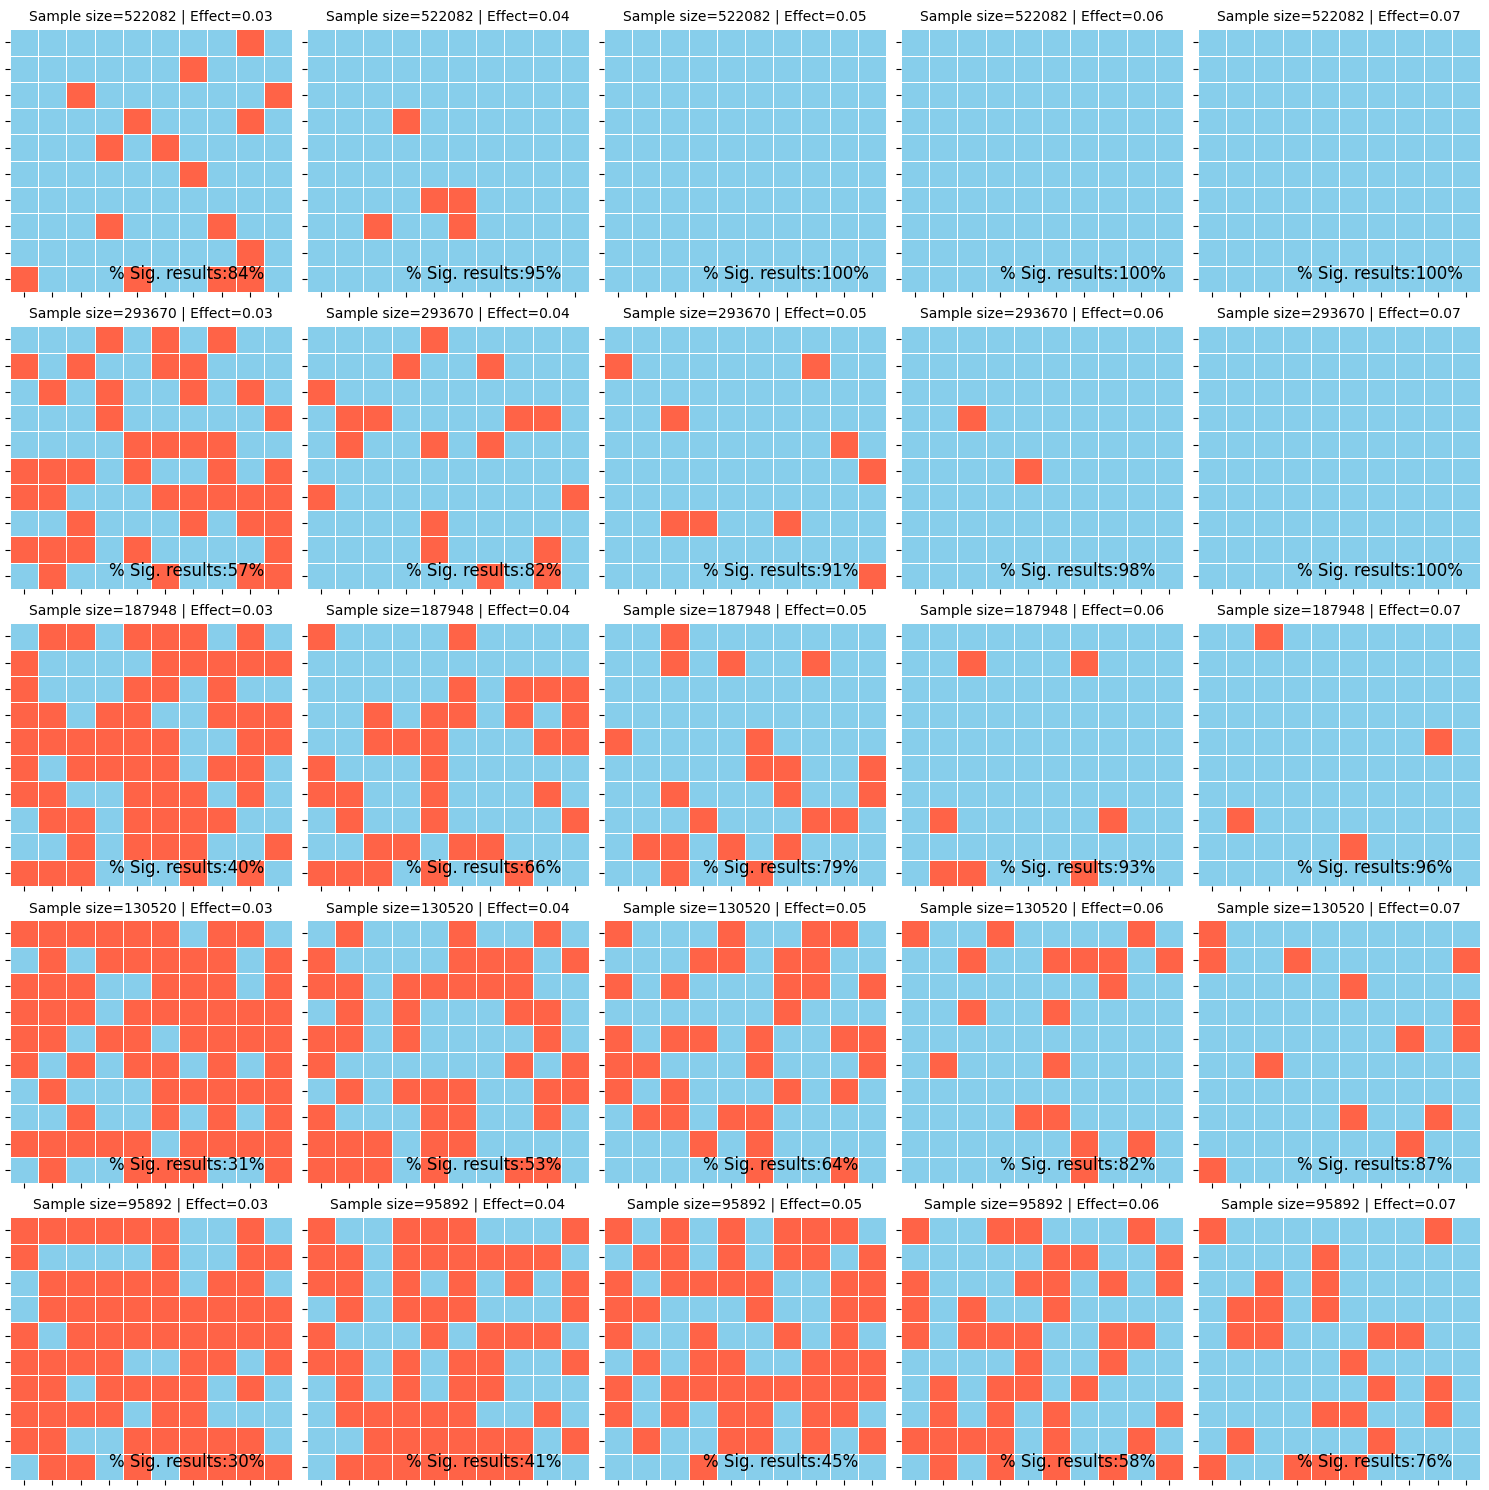

In [9]:
def draw_heatmap(data, row_var, col_var, value_var, **kwargs):
    data_pivot = data.pivot(
        index=row_var, columns=col_var, values=value_var
    )
    sns.heatmap(
        data_pivot,
        **kwargs
    )
    

def annotate_mean(data, metric, **kwargs):
    tx_mean = data[metric].mean()
    tx_mean = f"% Sig. results:{data[metric].mean():.0%}"
    txkw = dict(size=12)
    plt.text(3.5, 9.5, tx_mean, **txkw)
    

g = sns.FacetGrid(
    stats,
    col='true_effect',
    row='sample_size',
    height=3, aspect=1,
    row_order=sample_sizes
    
)
g.map_dataframe(draw_heatmap, row_var='index_row', col_var='index_col', value_var='sig_at',
                vmin=0,vmax=1,
                cmap=ListedColormap(['tomato', 'skyblue']),
                annot=False, linewidth=0.5, alpha=1, cbar=False
               )
g.map_dataframe(annotate_mean, metric='sig_at')


for ax in g.axes.flatten():
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    
g.set_titles(row_template="Sample size={row_name}", col_template="Effect={col_name}")
g.figure.tight_layout()

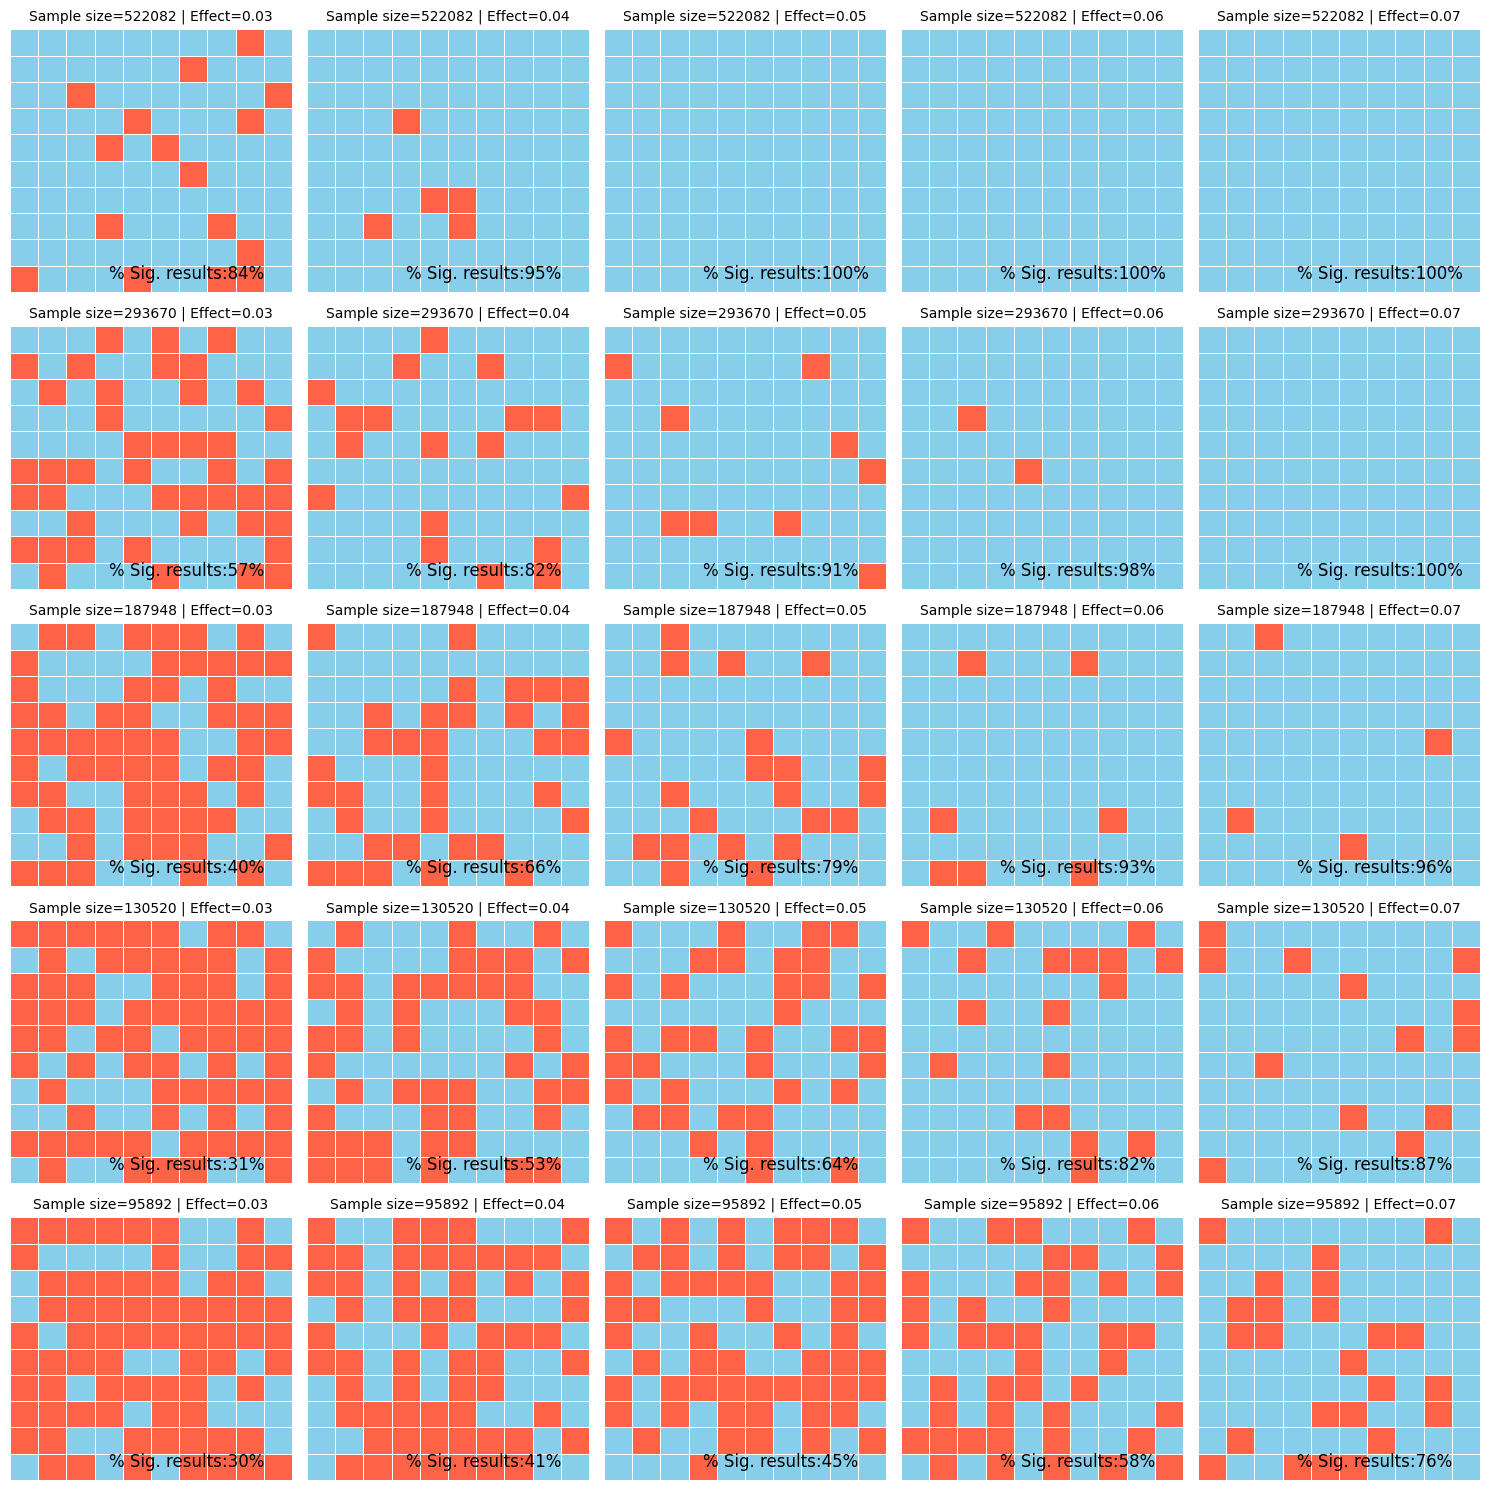

In [10]:
g = sns.FacetGrid(
    stats,
    col='true_effect',
    row='sample_size',
    height=3, aspect=1,
    row_order=sample_sizes
    
)
g.map_dataframe(draw_heatmap, row_var='index_row', col_var='index_col', value_var='sig_at',
                vmin=0,vmax=1,
                cmap=ListedColormap(['tomato', 'skyblue']),
                annot=False, linewidth=0.5, alpha=1, cbar=False
               )
g.map_dataframe(annotate_mean, metric='sig_at')


for ax in g.axes.flatten():
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_xticks([])
    ax.set_yticks([])
    
g.set_titles(row_template="Sample size={row_name}", col_template="Effect={col_name}")
g.figure.tight_layout()

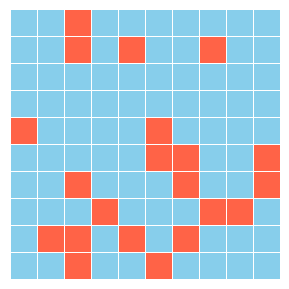

In [11]:
g = sns.FacetGrid(
        (stats.loc[
        (stats['count_sig']>=10) &
        (stats['sample_size']==187948) &
        (stats['true_effect']==0.05)
    ]),
#     col='true_effect',
#     row='sample_size',
    height=3, aspect=1,
    row_order=sample_sizes
    
)
g.map_dataframe(draw_heatmap, row_var='index_row', col_var='index_col', value_var='sig_at',
                vmin=0,vmax=1,
                cmap=ListedColormap(['tomato', 'skyblue']),
                annot=False, linewidth=0.5, alpha=1, cbar=False
               )
# g.map_dataframe(annotate_mean, metric='sig_at')


for ax in g.axes.flatten():
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_xticks([])
    ax.set_yticks([])
    
# g.set_titles(row_template="Sample size={row_name}", col_template="Effect={col_name}")
g.figure.tight_layout()

In [12]:
stats.head()

,estimate,ci_l,ci_h,p-value,true_effect,sample_size,index_row,index_col,sig_at,count_sig
"0.03,52208200,0",0.035270,0.015079,0.055871,0.003795,0.03,522082,0.0,0.0,1,84
"0.03,52208200,1",0.047323,0.026767,0.068301,0.000125,0.03,522082,0.0,1.0,1,84
"0.03,52208200,2",0.030217,0.010069,0.050773,0.013169,0.03,522082,0.0,2.0,1,84
"0.03,52208200,3",0.032091,0.012005,0.052582,0.008204,0.03,522082,0.0,3.0,1,84
"0.03,52208200,4",0.036575,0.016372,0.057188,0.002684,0.03,522082,0.0,4.0,1,84


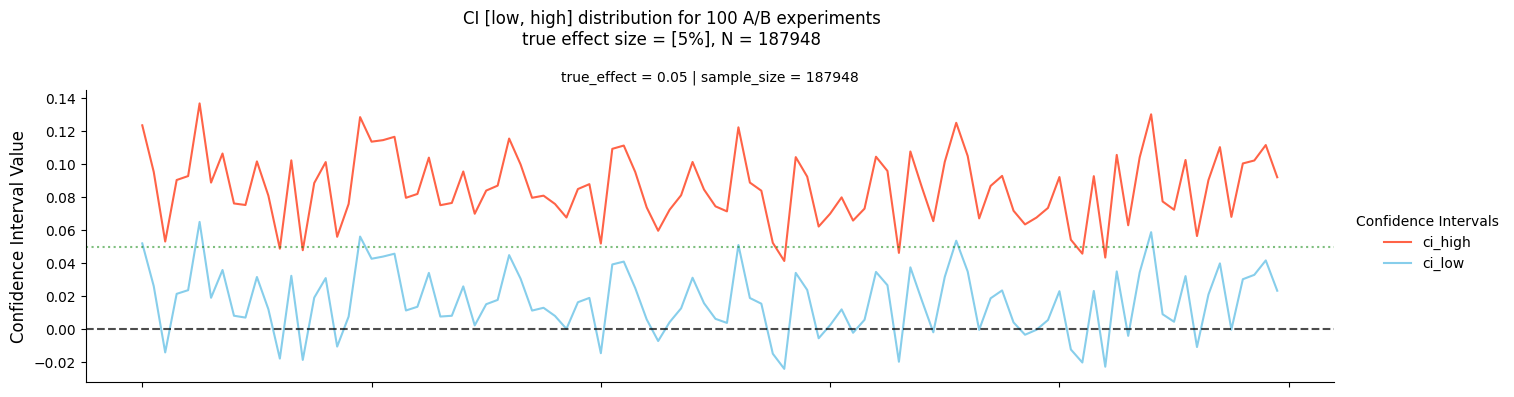

In [13]:
stats['index'] = [i for i in range(len(stats))]

stats_plot = stats.loc[
        (stats['true_effect']==0.05) & (stats['sample_size']==187948)  
             ]

g = sns.FacetGrid(
    stats_plot,
    col = 'sample_size', row = 'true_effect',
    height=4, aspect=3, sharex=True, 
)

g.map_dataframe(
    sns.lineplot,
    x='index',
    y='ci_h',
    color='tomato',
    label='ci_high'
)

g.map_dataframe(
    sns.lineplot,
    x='index',
    y='ci_l',
    color='skyblue',
    label='ci_low'
)

g.refline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
g.refline(y=0.05, color='green', linestyle=':', linewidth=1.5, alpha=0.5)


for ax in g.axes.flatten():
    ax.set_xlabel('')
    ax.set_ylabel('CI')
    ax.set_xticklabels([])
    
# Add axis labels
g.set_axis_labels('', 'Confidence Interval Value', fontsize=12)

# Add legend
g.add_legend(title='Confidence Intervals', fontsize=10)
sns.move_legend(g, "upper right", bbox_to_anchor=(1.12, 0.5), frameon=False)
    
g.fig.suptitle(f"CI [low, high] distribution for 100 A/B experiments\ntrue effect size = [{stats_plot.true_effect.unique()[0]:.0%}], N = {stats_plot.sample_size.unique()[0]}")
g.fig.tight_layout()


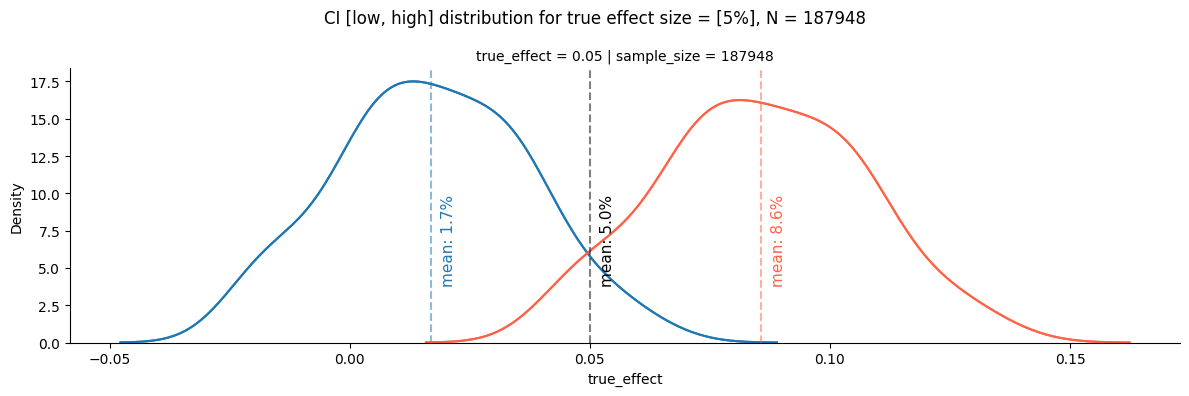

In [14]:
g = sns.FacetGrid(
    stats.loc[
        (stats['true_effect']==0.05) & (stats['sample_size']==187948)  
             ],
    col = 'sample_size', row = 'true_effect',
    height=4, aspect=3, sharex=True, 
)

g.map_dataframe(sns.kdeplot, x='ci_l')
g.map(sns.kdeplot, 'ci_l')
g.map(vertical_plot_lines, 'ci_l', xal=0.002, yal=4)

g.map_dataframe(sns.kdeplot, x='ci_h', color='tomato')
g.map(sns.kdeplot, 'ci_h', color='tomato')
g.map(vertical_plot_lines, 'ci_h', color='tomato', xal=0.002, yal=4)
g.map(vertical_plot_lines, 'true_effect', linestyle = '--', color='black', xal=0.002, yal=4)

g.fig.suptitle("CI [low, high] distribution for true effect size = [5%], N = 187948")
g.fig.tight_layout()

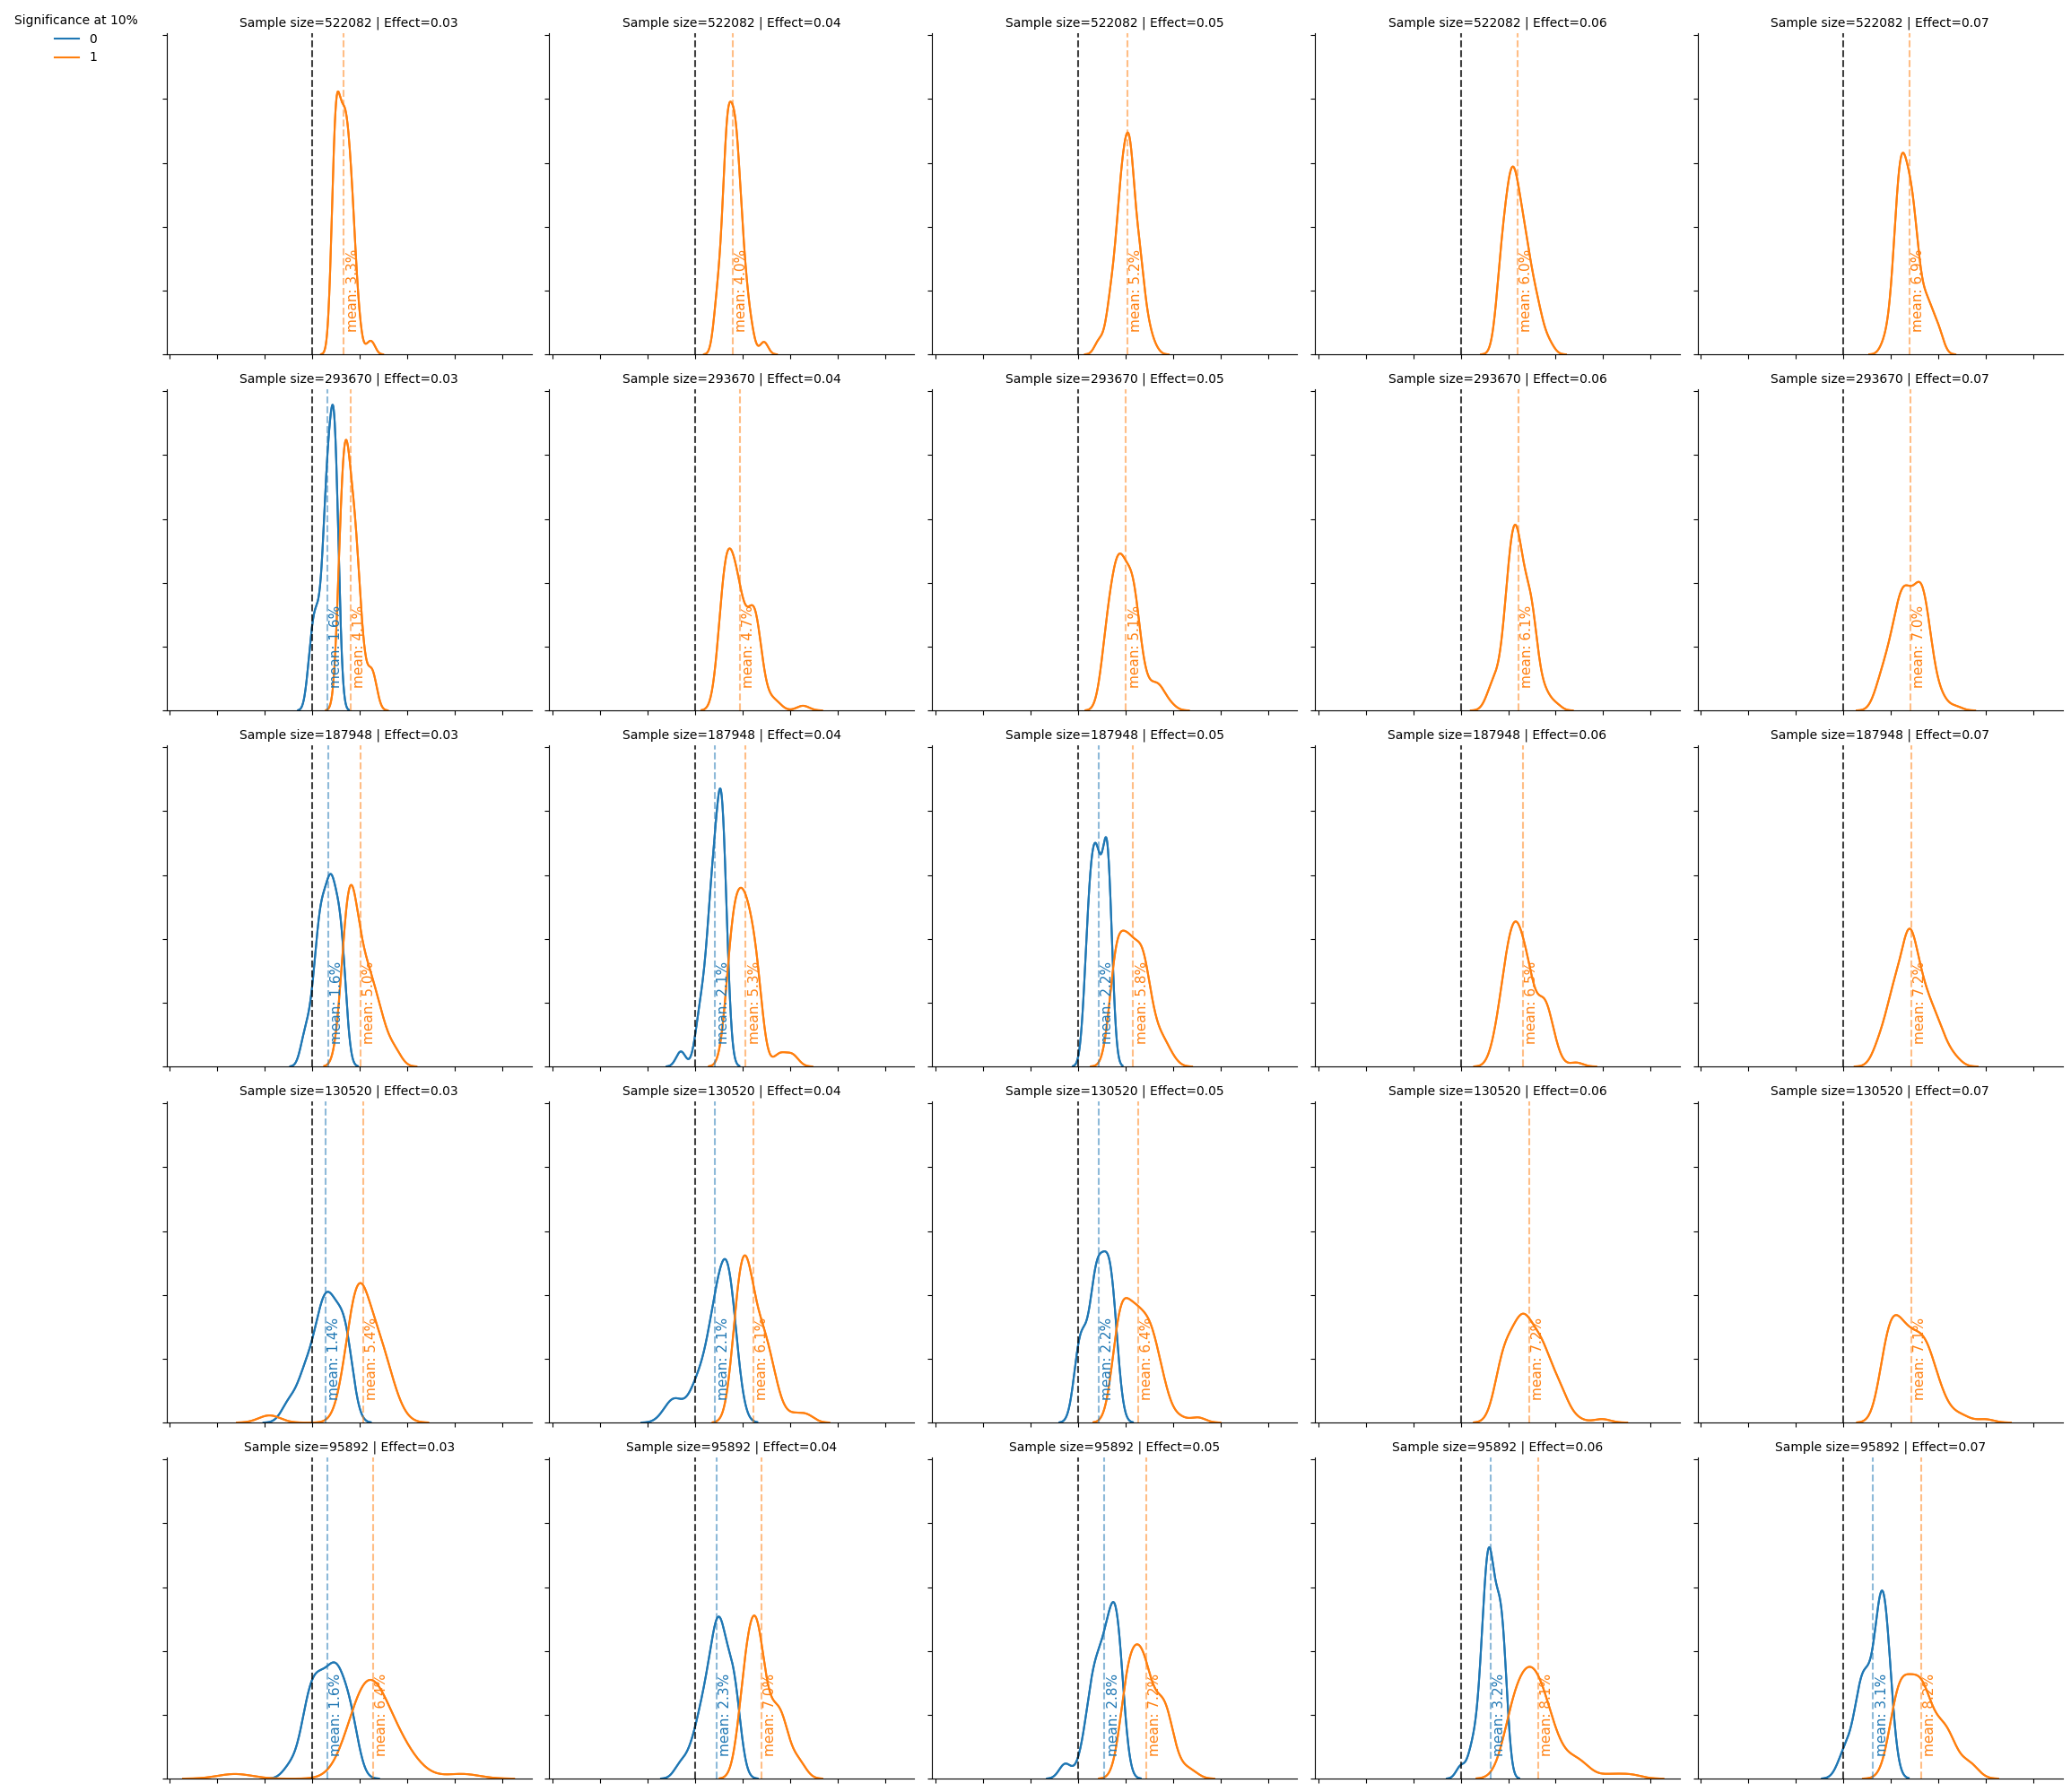

In [15]:
g = sns.FacetGrid(
    stats.loc[stats['count_sig']>=20],
    col='true_effect',
    row='sample_size',
    hue='sig_at',
    height=4, aspect=1, sharex=True,
    row_order=sample_sizes
    
)
g.map_dataframe(sns.kdeplot, x='estimate')
g.map(sns.kdeplot, 'estimate')
g.map(vertical_plot_lines, 'estimate', xal=0.002, yal=4)
# g.map(vertical_plot_lines, 'true_effect', xal=0.005, yal=50, color='tomato')


for ax in g.axes.flatten():
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticklabels([])
    ax.set_yticklabels([])

    ax.axvline(0, linestyle = '--', color = "black", alpha = 0.75)
# plt.axvline(stats['true_effect'].mean(), linestyle = ':', color = "black", alpha = 0.75)
# plt.text(stats['true_effect'].mean()+0.0015, 4, f"True effect: {stats['true_effect'].mean():.1%}", rotation=90)
    
    
g.add_legend(title="Significance at 10%")
sns.move_legend(g, "upper right", bbox_to_anchor=(0, 1), frameon=False)
g.set_titles(row_template="Sample size={row_name}", col_template="Effect={col_name}")
g.figure.tight_layout()

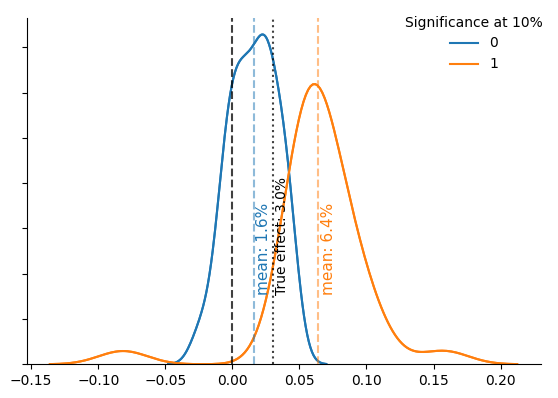

In [16]:
plot_stats = stats.loc[
        (stats['count_sig']>=10) &
        (stats['sample_size']<96892) &
        (stats['true_effect']==0.03)
    ]

g = sns.FacetGrid(
    plot_stats,
#     col='true_effect',
#     row='sample_size',
    hue='sig_at',
    height=4, aspect=1, sharex=True,
    row_order=sample_sizes
    
)
g.map_dataframe(sns.kdeplot, x='estimate')
g.map(sns.kdeplot, 'estimate')
g.map(vertical_plot_lines, 'estimate', xal=0.002, yal=4)
# g.map(vertical_plot_lines, 'true_effect', xal=0.005, yal=50, color='tomato')


for ax in g.axes.flatten():
    ax.set_xlabel('')
    ax.set_ylabel('')
#     ax.set_xticklabels([])
    ax.set_yticklabels([])

plt.axvline(0, linestyle = '--', color = "black", alpha = 0.75)
plt.axvline(plot_stats['true_effect'].mean(), linestyle = ':', color = "black", alpha = 0.75)
plt.text(plot_stats['true_effect'].mean()+0.0015, 4, f"True effect: {plot_stats['true_effect'].mean():.1%}", rotation=90)
    
    
g.add_legend(title="Significance at 10%")
sns.move_legend(g, "upper right", bbox_to_anchor=(1, 1), frameon=False)
g.set_titles(row_template="Sample size={row_name}", col_template="Effect={col_name}")
g.figure.tight_layout()

# Non parametric test

In [17]:
def vertical_plot_lines(x, xal, yal, **kwargs):
    plt.axvline(x.mean(), linestyle = '--', color = kwargs.get("color", "g"), alpha = 0.5)
    tx_mean = "mean: {:.1%}".format(x.mean())
    txkw = dict(size=11, color = kwargs.get("color", "g"), rotation=90)
    plt.text(x.mean()+xal, yal, tx_mean, **txkw)


def plot_distribution(df, metric, **kwargs):
    g = sns.FacetGrid(
        data=df,
        aspect=3, height = 5,
        hue = 'variant', row = kwargs.get('row',None)
    ) 
    g.map(sns.distplot, metric, hist=kwargs.get('displot_hist',False), kde_kws={'bw': kwargs.get('kde_bandwidth','silverman')})
    g.map(vertical_plot_lines, metric, xal=  kwargs.get('xal',0.10), yal=kwargs.get('yal',0.5))
    g.fig.suptitle("Distribution between variants - {}".format(metric))
    g.set_xlabels("{}".format(metric))
    g.set_ylabels("density")
    g.set(xlim = kwargs.get('xlim', (-10,10)))
    g.add_legend()
    plt.subplots_adjust(top=0.9)
    for ax in g.axes:
        ax[0].axvline(x=0, color="black", ls=':')
        
        
def get_mann_whitney_test(data, metric_field, confidence=0.9):
    array_base = data.loc[data['variant'] == 0, metric_field]
    array_variant = data.loc[data['variant'] == 1, metric_field]
    u_value, p_value = mannwhitneyu(array_base, array_variant)
    
    print("Mann-Whitney p-value: {:.5f} \nstatstistical significance at {} level p_value < (1 - confidence): {}\n".format(
        p_value, confidence, p_value<(1-confidence)))
    
    return u_value, p_value
                
    

/opt/homebrew/lib/python3.9/site-packages/seaborn/axisgrid.py:854: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751


/opt/homebrew/lib/python3.9/site-packages/seaborn/distributions.py:2496: UserWarning:



The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=silverman`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.14.0.


/opt/homebrew/lib/python3.9/site-packages/seaborn/axisgrid.py:854: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level funct

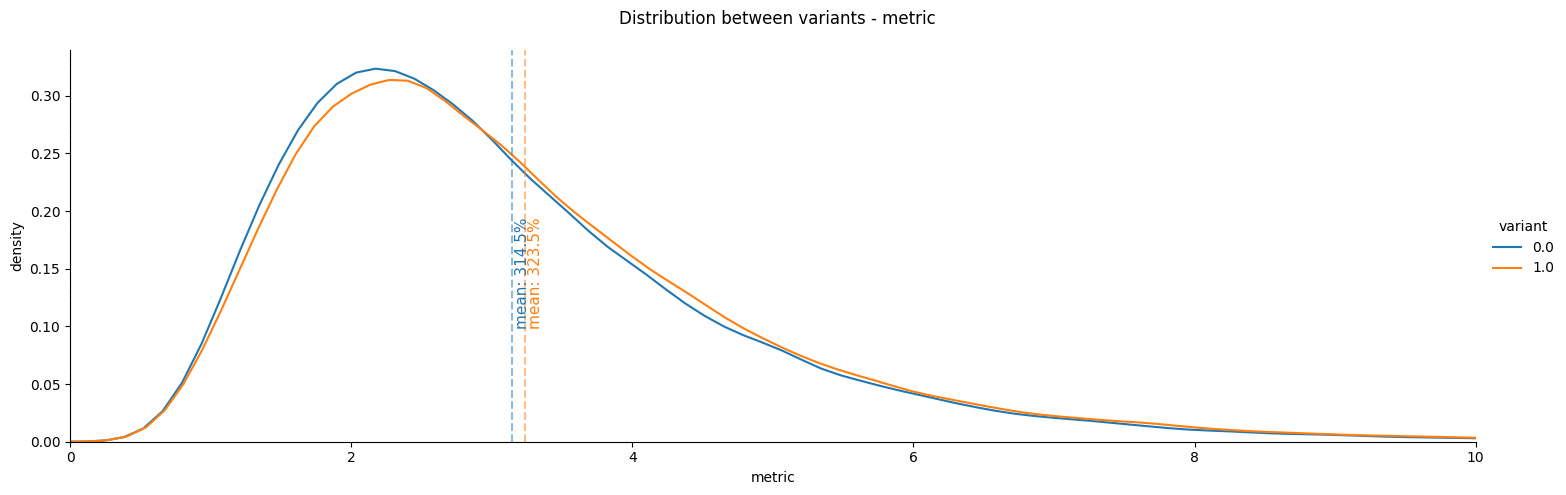

In [18]:
df_exp = pd.DataFrame({'variant': np.round(np.random.uniform(0,1,SAMPLE_SIZE))})

df_exp['metric'] = np.random.lognormal(
    1.02, 
    .5,
    SAMPLE_SIZE
)

df_exp.loc[df_exp.variant == 1, 'metric'] = np.random.lognormal(
    1.05, 
    .5,
    size=df_exp.loc[df_exp.variant == 1, 'metric'].shape[0]
)

plot_distribution(
    df_exp, 
    'metric', xlim=(0,10),
    yal=0.1, xal=0.02)

In [19]:
get_mann_whitney_test(df_exp, 'metric', confidence=0.9)

Mann-Whitney p-value: 0.00000 
statstistical significance at 0.9 level p_value < (1 - confidence): True



(np.float64(7561688727.0), np.float64(6.217787899899839e-44))

# A/A simulations

In [20]:
def run_simulation(
    num_simulations=500,
    sample_size=100000,
    true_effect = 0.0,
    base_rate = 0.05,
    ci_l_threshold = -0.01
):       
    counter_trending = 0
    counter_result_changed = 0
    responses = {}
    for i in tqdm(range(num_simulations)):

        df_exp = pd.DataFrame({'variant': np.round(np.random.uniform(0,1,sample_size))})

        df_exp['metric'] = np.random.binomial(
            n=1, 
            p=base_rate, 
            size=sample_size
        )

        df_exp.loc[df_exp.variant == 1, 'metric'] = np.random.binomial(
            n=1, 
            p=base_rate * (1 + true_effect), 
            size=df_exp.loc[df_exp.variant == 1, 'metric'].shape[0]
        )

        response = get_results(
            df_exp, 
            metric_field='metric', 
            confidence=0.9, 
            threshold=None, 
            calculate_ratio=True,
            plot=False
        )

        if (response['ci_l'] > ci_l_threshold) & (response['ci_l'] <= 0):

            counter_trending += 1

            df_exp_2 = pd.DataFrame({'variant': np.round(np.random.uniform(0,1,sample_size))})

            df_exp_2['metric'] = np.random.binomial(
                n=1, 
                p=base_rate, 
                size=sample_size
            )

            df_exp_2.loc[df_exp_2.variant == 1, 'metric'] = np.random.binomial(
                n=1, 
                p=BASE_RATE * (1 + true_effect), 
                size=df_exp_2.loc[df_exp_2.variant == 1, 'metric'].shape[0]
            )

            df_exp = pd.concat([df_exp, df_exp_2])

            response_2 = get_results(
                df_exp, 
                metric_field='metric', 
                confidence=0.9, 
                threshold=None, 
                calculate_ratio=True,
                plot=False
            )

            if response_2['ci_l'] > 0:
                counter_result_changed += 1


        response['true_effect'] = true_effect
        response['sample_size'] = sample_size
        response['index_row'] = int(i // 10)
        response['index_col'] = int(i % 10)

        responses[f'{true_effect},{sample_size*100},{i}'] = response

    stats = pd.DataFrame(responses).T 
    stats['sample_size'] = stats['sample_size'].apply(int)
    stats['sig_at'] = stats['p-value'] <= 0.1
    stats['sig_at'] = stats['sig_at'] * 1

    stats['count_sig'] = stats.groupby(['true_effect','sample_size','sig_at'])['sig_at'].transform('count')
    
    return stats, counter_trending, counter_result_changed

In [21]:
RANGE = 1000
stats, counter_trending, counter_result_changed = run_simulation(
    num_simulations=RANGE,
    sample_size=100000,
    true_effect = 0.0,
    base_rate = 0.05,
    ci_l_threshold = -0.01
)

  2%|███▍                                                                                                                                                                                                                                    | 15/1000 [00:00<00:06, 140.76it/s]


pval = 0.89956, significant at 10%: False


pval = 0.13111, significant at 10%: False


pval = 0.63991, significant at 10%: False


pval = 0.52589, significant at 10%: False


pval = 0.40295, significant at 10%: False


pval = 0.55209, significant at 10%: False


pval = 0.64364, significant at 10%: False


pval = 0.36873, significant at 10%: False


pval = 0.01699, significant at 10%: True


pval = 0.40576, significant at 10%: False


pval = 0.04210, significant at 10%: True


pval = 0.41684, significant at 10%: False


pval = 0.11333, significant at 10%: False


pval = 0.45227, significant at 10%: False


pval = 0.80326, significant at 10%: False


pval = 0.15703, significant at 10%: False


pval = 0.00815, significant at 10%: True


pval = 0.23417, significant at 10%: False


pval = 0.11168, significant at 10%: False


pval = 0.66826, significant at 10%: False


pval = 0.03775, significant at 10%: True


pval = 0.03927, significant at 10%: True


pval = 0.86039, significant at 10%: 

  4%|██████████▏                                                                                                                                                                                                                             | 44/1000 [00:00<00:07, 132.64it/s]


pval = 0.60572, significant at 10%: False


pval = 0.78780, significant at 10%: False


pval = 0.86793, significant at 10%: False


pval = 0.83799, significant at 10%: False


pval = 0.32981, significant at 10%: False


pval = 0.40086, significant at 10%: False


pval = 0.75321, significant at 10%: False


pval = 0.09735, significant at 10%: True


pval = 0.86055, significant at 10%: False


pval = 0.09707, significant at 10%: True


pval = 0.04186, significant at 10%: True


pval = 0.12965, significant at 10%: False


pval = 0.58748, significant at 10%: False


pval = 0.70371, significant at 10%: False


pval = 0.37152, significant at 10%: False


pval = 0.50911, significant at 10%: False


pval = 0.86371, significant at 10%: False


pval = 0.79246, significant at 10%: False


pval = 0.71271, significant at 10%: False


pval = 0.60311, significant at 10%: False


pval = 0.36035, significant at 10%: False


pval = 0.43991, significant at 10%: False


pval = 0.84912, significant at 10%

  7%|████████████████▉                                                                                                                                                                                                                       | 73/1000 [00:00<00:06, 136.42it/s]

...


pval = 0.94552, significant at 10%: False


pval = 0.80649, significant at 10%: False



 98%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌   | 985/1000 [00:07<00:00, 132.96it/s]


pval = 0.05334, significant at 10%: True


pval = 0.47598, significant at 10%: False


pval = 0.29076, significant at 10%: False


pval = 0.78748, significant at 10%: False


pval = 0.75469, significant at 10%: False


pval = 0.77829, significant at 10%: False


pval = 0.79402, significant at 10%: False


pval = 0.67564, significant at 10%: False


pval = 0.84356, significant at 10%: False


pval = 0.06170, significant at 10%: True


pval = 0.43266, significant at 10%: False


pval = 0.02251, significant at 10%: True


pval = 0.62990, significant at 10%: False


pval = 0.31952, significant at 10%: False


pval = 0.70194, significant at 10%: False


pval = 0.88198, significant at 10%: False


pval = 0.41702, significant at 10%: False


pval = 0.47343, significant at 10%: False


pval = 0.37231, significant at 10%: False


pval = 0.98040, significant at 10%: False


pval = 0.82777, significant at 10%: False


pval = 0.27763, significant at 10%: False


pval = 0.01369, significant at 10%

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:07<00:00, 135.73it/s]


pval = 0.59088, significant at 10%: False

CI trending: 35, % of total: 3.50%
Result changed after run longer: 4, % of total: 0.40%


In [22]:
print(f"CI trending: {counter_trending}, % of total: {counter_trending/RANGE:.2%}")
print(f"Result changed after run longer: {counter_result_changed}, % of total: {counter_result_changed/RANGE:.2%}")

CI trending: 35, % of total: 3.50%
Result changed after run longer: 4, % of total: 0.40%


In [23]:
stats.describe()

,estimate,ci_l,ci_h,p-value,true_effect,sample_size,index_row,index_col,sig_at,count_sig
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.0,1000.0,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.000218,-0.044156,0.046652,0.504764,0.0,100000.0,49.500000,4.500000,0.091000,834.562000
std,0.026941,0.025764,0.028207,0.285226,0.0,0.0,28.880514,2.873719,0.287753,235.381972
min,-0.075040,-0.116612,-0.031601,0.002841,0.0,100000.0,0.000000,0.000000,0.000000,91.000000
25%,-0.018341,-0.061902,0.027394,0.271863,0.0,100000.0,24.750000,2.000000,0.000000,909.000000
50%,0.000941,-0.043618,0.047394,0.499191,0.0,100000.0,49.500000,4.500000,0.000000,909.000000
75%,0.019091,-0.026147,0.066305,0.754048,0.0,100000.0,74.250000,7.000000,0.000000,909.000000
max,0.086686,0.038025,0.137736,0.998336,0.0,100000.0,99.000000,9.000000,1.000000,909.000000


In [24]:
print(((stats.ci_l >= 0.0) | (stats.ci_h <= 0.0)).mean()) # alpha | false positive
print(((stats.ci_l >= -0.01) | (stats.ci_h <= 0.01)).mean()) # borderline alpha | false positive
print(((stats.ci_l >= -0.02) | (stats.ci_h <= 0.02)).mean()) # borderline alpha | false positive

0.091
0.182
0.354


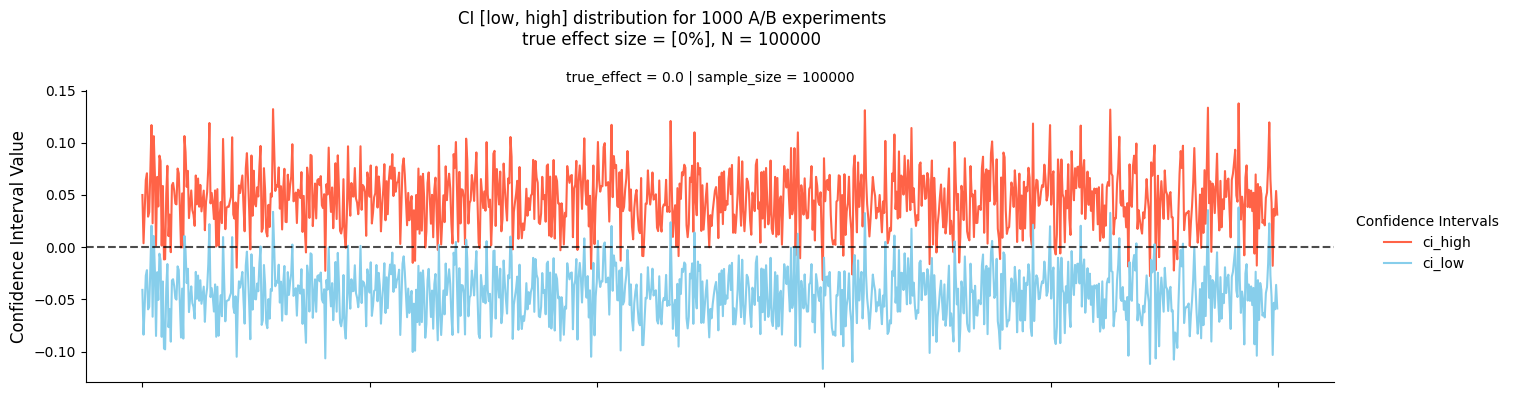

In [25]:
stats['index'] = [i for i in range(len(stats))]

stats_plot = stats.copy()

g = sns.FacetGrid(
    stats_plot,
    col = 'sample_size', row = 'true_effect',
    height=4, aspect=3, sharex=True, 
)

g.map_dataframe(
    sns.lineplot,
    x='index',
    y='ci_h',
    color='tomato',
    label='ci_high'
)

g.map_dataframe(
    sns.lineplot,
    x='index',
    y='ci_l',
    color='skyblue',
    label='ci_low'
)

g.refline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
# g.refline(y=0.05, color='green', linestyle=':', linewidth=1.5, alpha=0.5)


for ax in g.axes.flatten():
    ax.set_xlabel('')
    ax.set_ylabel('CI')
    ax.set_xticklabels([])
    
# Add axis labels
g.set_axis_labels('', 'Confidence Interval Value', fontsize=12)

# Add legend
g.add_legend(title='Confidence Intervals', fontsize=10)
sns.move_legend(g, "upper right", bbox_to_anchor=(1.12, 0.5), frameon=False)
    
g.fig.suptitle(f"CI [low, high] distribution for {RANGE} A/B experiments\ntrue effect size = [{stats_plot.true_effect.unique()[0]:.0%}], N = {stats_plot.sample_size.unique()[0]}")
g.fig.tight_layout()
